Study assimilation - postprocess PRO files

In [1]:
# from edelassim.postprocess_surfex.pro import postprocess_pro
# Preprocess simulation output (assimilation of snow depth in this case)
import glob
from datetime import timedelta

import numpy as np
import xarray as xr
from pandas import date_range
from pyproj import CRS
import pandas as pd
from edelassim.postprocess_surfex.pro import postprocess_pro
simulation_folder = "/home/imperatoren/work/edelweiss_assimilation/simulations/edelweiss/grandesrousses250m/open_loop"
output_folder = "/home/imperatoren/work/edelweiss_assimilation/simulations/postprocess/grandesrousses250m/open_loop/"
filename = "all_members/pro/PRO_daily_snowdepth_avg_grandesrousses_20212022.nc"
output_file = f"{output_folder}/{filename}"


sd_analysis = postprocess_pro(simulation_folder=simulation_folder, output_file=None)

open mb0000


<frozen importlib._bootstrap>:241: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


open mb0001
open mb0002
open mb0003
open mb0004
open mb0005
open mb0006
open mb0007
open mb0008
open mb0009
open mb0010
open mb0011
open mb0012
open mb0013
open mb0014
open mb0015
open mb0016
concatenating all members


In [7]:
sd_analysis.sel(time='2022-02-22')

<xarray.Dataset> Size: 2MB
Dimensions:          (member: 17, y: 101, x: 143)
Coordinates:
  * x                (x) float64 1kB 9.379e+05 9.381e+05 ... 9.731e+05 9.734e+05
  * y                (y) float64 808B 6.439e+06 6.439e+06 ... 6.464e+06
    time             datetime64[ns] 8B 2022-02-22
  * member           (member) int64 136B 0 1 2 3 4 5 6 ... 10 11 12 13 14 15 16
    Projection_Type  int64 8B 0
Data variables:
    DSN_T_ISBA       (member, y, x) float64 2MB dask.array<chunksize=(1, 101, 143), meta=np.ndarray>
Attributes: (12/41)
    references:                    https://doi.org/10.5194/essd-14-1707-2022
    keywords_vocabulary:           GCMD
    conventions:                   ACDD-1.3,CF-1.7
    naming_authority:              fr.umr-cnrm.cen
    acknowledgement:               Many contributors have developed and maint...
    standard_name_vocabulary:      CF Standard Name Table v67
    ...                            ...
    snowtools_commit:              
    python_version:                3.10.12 | packaged by conda-forge | (main,...
    python_binary:                 /opt/softs/anaconda3/envs/Python310/bin/py...
    title:                         S2M reanalysis: snow variables
    summary:                       This file takes part from a 61-years reana...
    keywords:                      MOUNTAINS,SNOW WATER EQUIVALENT,SNOW,ALBED...

In [8]:
sd_analysis.sel(time='2022-02-22').to_netcdf('PRO_daily_snowdepth_grandesrousses_22february2022.nc')

Postprocess prep

In [11]:
from pyproj import CRS
import glob
from edelassim.postprocess_surfex.prep import compute_all_members_snow_tickness_and_mass
from edelassim.observation_operators import zaitchik

# from postprocess_surfex.prep import compute_snow_thickness_from_prep
slope_file = "/home/imperatoren/work/edelweiss_assimilation/data/auxiliary/topography/slope.tif"
new_prep_analysis = compute_all_members_snow_tickness_and_mass(
    simulation_folder=simulation_folder, slope_file=slope_file, type="analysis"
)
new_prep_analysis = new_prep_analysis.assign(
    {"fsc": zaitchik(swe=new_prep_analysis.data_vars["swe"], tau_scf=4, swe_full_snow_cover=200)}
)
filename = "all_members/prep/analysis/PREP_2022026_zaitchik.nc"
output_file = f"{output_folder}/{filename}"
new_prep_analysis.to_netcdf(output_file)

new_prep_background = compute_all_members_snow_tickness_and_mass(
    simulation_folder=simulation_folder, slope_file=slope_file, type="background"
)
new_prep_background = new_prep_background.assign(
    {"fsc": zaitchik(swe=new_prep_background.data_vars["swe"], tau_scf=4, swe_full_snow_cover=200)}
)
filename = "all_members/prep/background/PREP_2022026_zaitchik.nc"
output_file = f"{output_folder}/{filename}"
new_prep_background.to_netcdf(output_file)

In [3]:
import glob
from edelassim.postprocess_surfex.prep import compute_all_members_snow_tickness_and_mass

simulation_folder = "/home/imperatoren/work/edelweiss_assimilation/simulations/edelweiss/grandesrousses250m/assim_viirs_local"
prep_bg_files = sorted(glob.glob(f"{simulation_folder}/PREP_220226H12_PF_ENS*.nc"))
prep_an_files = sorted(glob.glob(f"{simulation_folder}/SURFOUT*.nc"))

bg = compute_all_members_snow_tickness_and_mass(
    prep_files=prep_bg_files,
    slope_file="/home/imperatoren/work/edelweiss_assimilation/data/grandesrousses/auxiliary/topography/slope.tif",
)

an = compute_all_members_snow_tickness_and_mass(
    prep_files=prep_an_files,
    slope_file="/home/imperatoren/work/edelweiss_assimilation/data/grandesrousses/auxiliary/topography/slope.tif",
)

# bg.to_netcdf(f"{simulation_folder}/prep_bg_all.nc")
an.to_netcdf(f"{simulation_folder}/prep_an_all.nc")

In [38]:
import xarray as xr
import numpy as np


def zaitchik(swe: np.ndarray, tau_scf: int = 4, swe_full_snow_cover: int = 20) -> np.ndarray:
    return np.minimum(1 - (np.exp(-tau_scf * (swe / swe_full_snow_cover)) - (swe / swe_full_snow_cover) * np.exp(-tau_scf)), 1)


simulation_folder = "/home/imperatoren/work/edelweiss_assimilation/simulations/edelweiss/grandesrousses250m/assim_viirs_local"
background = xr.open_dataset((f"{simulation_folder}/prep_bg_all.nc"))
analysis = xr.open_dataset((f"{simulation_folder}/prep_an_all.nc"))
obs = xr.open_dataset((f"{simulation_folder}/OBSERVATIONS_220226H12.nc"))
obs = obs.rename({"xx":"x","yy":"y" })

Text(0.5, 1.0, 'Analysis - Background')

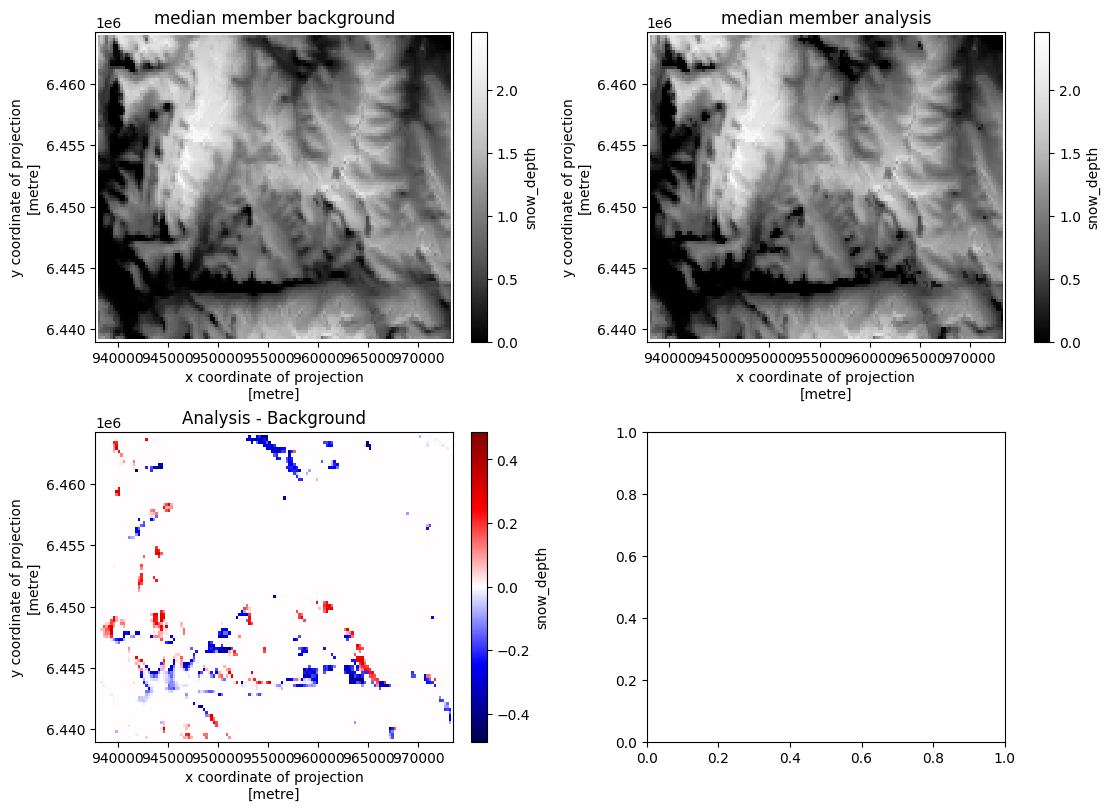

In [51]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
background.data_vars["snow_depth"].median(dim="member").plot.imshow(ax=axs[0,0], cmap="Greys_r")
axs[0,0].set_title("median member background")
analysis.data_vars["snow_depth"].median(dim="member").plot.imshow(ax=axs[0,1], cmap="Greys_r")
axs[0,1].set_title("median member analysis")
(analysis.data_vars["snow_depth"].median(dim="member") - background.data_vars["snow_depth"].median(dim="member")).plot.imshow(ax=axs[1,0], cmap="seismic")
axs[1,0].set_title("Analysis - Background")

Text(0.5, 1.0, 'Analysis - Background')

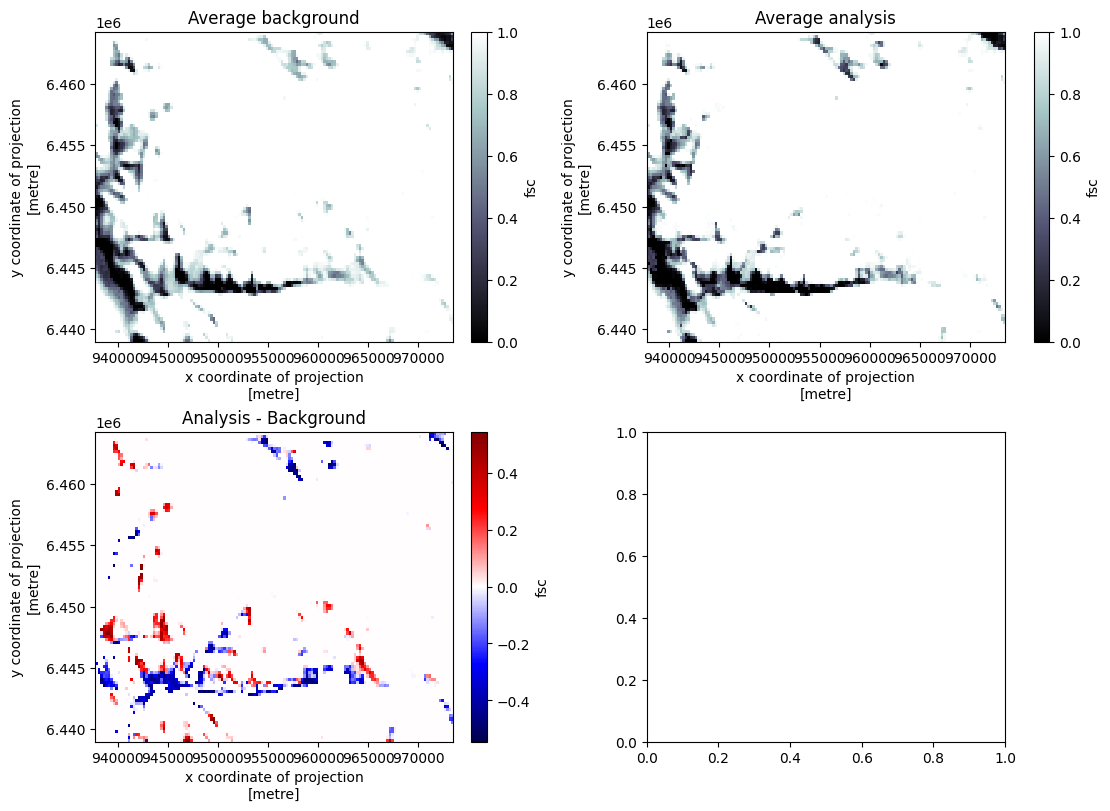

In [54]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
background = background.assign({"fsc": zaitchik(background.data_vars["swe"])})
background.mean(dim="member").data_vars["fsc"].plot.imshow(ax=axs[0,0],  cmap="bone")
axs[0,0].set_title("Average background")
analysis = analysis.assign({"fsc": zaitchik(analysis.data_vars["swe"])})
analysis.mean(dim="member").data_vars["fsc"].plot.imshow(ax=axs[0,1],  cmap="bone")
axs[0,1].set_title("Average analysis")
(analysis.mean(dim="member") - background.mean(dim="member")).data_vars["fsc"].plot.imshow(ax=axs[1,0],  cmap="seismic")
axs[1,0].set_title("Analysis - Background")

Text(0.5, 1.0, '(Background - observation)@at least one member not full snow')

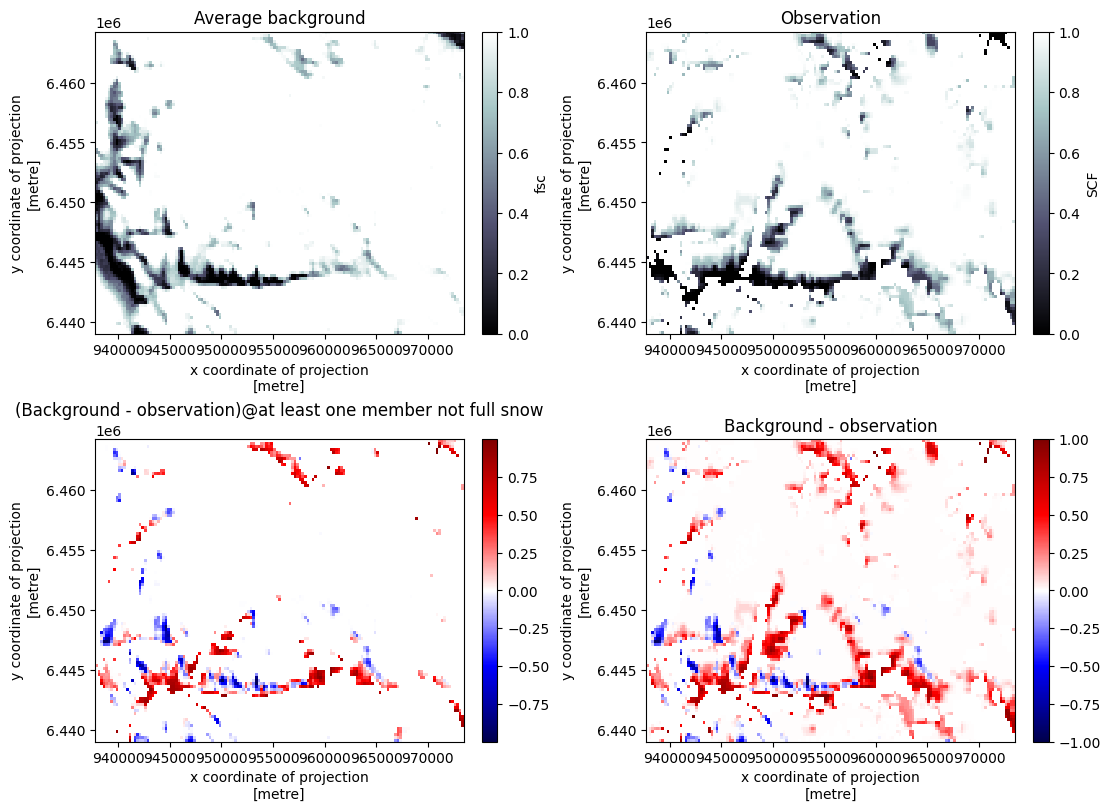

In [57]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
background = background.assign({"fsc": zaitchik(background.data_vars["swe"])})
background.mean(dim="member").data_vars["fsc"].plot.imshow(ax=axs[0,0],  cmap="bone")
axs[0,0].set_title("Average background")
obs.data_vars["SCF"].plot.imshow(ax=axs[0,1],  cmap="bone")
axs[0,1].set_title("Observation")
(background.mean(dim="member").data_vars["fsc"] - obs.data_vars["SCF"]).plot.imshow(ax=axs[1,1],  cmap="seismic")
axs[1,1].set_title("Background - observation")
(background.mean(dim="member").data_vars["fsc"] - obs.data_vars["SCF"]).where(background.mean(dim="member").data_vars["fsc"]<1).plot.imshow(ax=axs[1,0],  cmap="seismic")
axs[1,0].set_title("(Background - observation)@at least one member not full snow")

Text(0.5, 1.0, '(Analysis - observation)@at least one member not full snow')

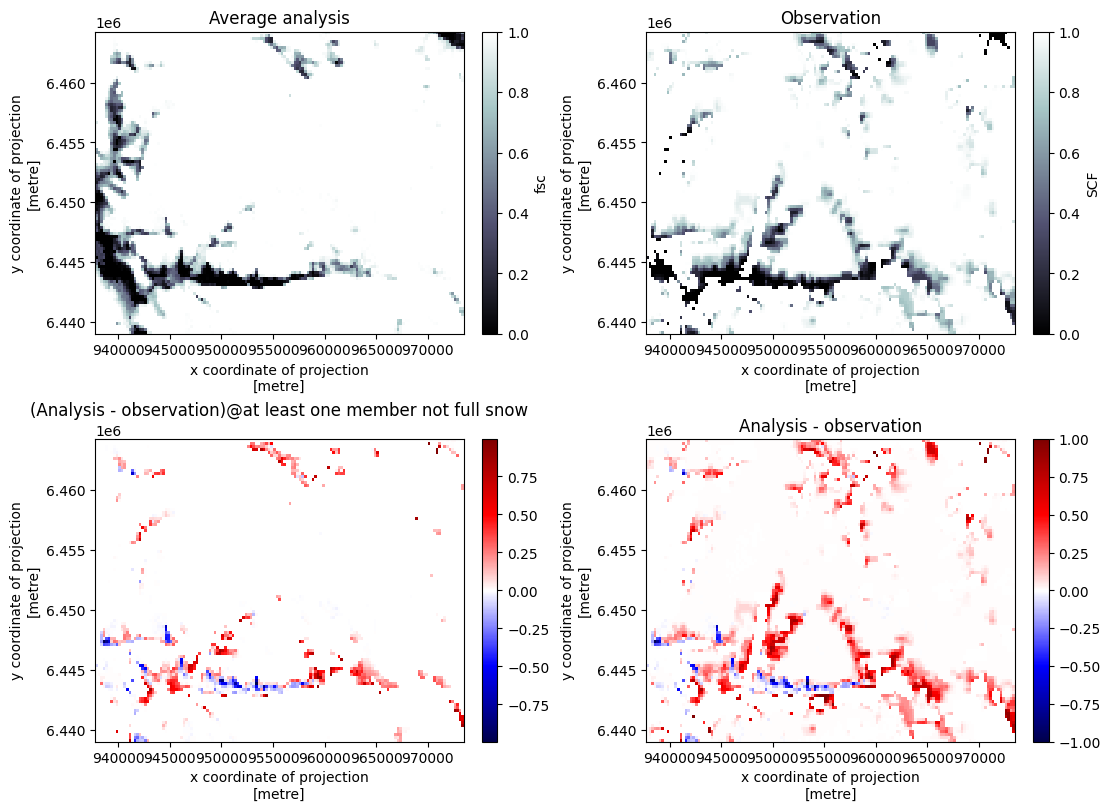

In [59]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
analysis = analysis.assign({"fsc": zaitchik(analysis.data_vars["swe"])})
analysis.mean(dim="member").data_vars["fsc"].plot.imshow(ax=axs[0,0],  cmap="bone")
axs[0,0].set_title("Average analysis")
obs.data_vars["SCF"].plot.imshow(ax=axs[0,1],  cmap="bone")
axs[0,1].set_title("Observation")
(analysis.mean(dim="member").data_vars["fsc"] - obs.data_vars["SCF"]).plot.imshow(ax=axs[1,1],  cmap="seismic")
axs[1,1].set_title("Analysis - observation")
# In the where we look in the background because that's where assimilation was active
(analysis.mean(dim="member").data_vars["fsc"] - obs.data_vars["SCF"]).where(background.mean(dim="member").data_vars["fsc"]<1).plot.imshow(ax=axs[1,0],  cmap="seismic")
axs[1,0].set_title("(Analysis - observation)@at least one member not full snow")

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(6, 11), constrained_layout=True)
background = background.assign({"fsc": zaitchik(background.data_vars["swe"])})
background.mean(dim="member").data_vars["fsc"].plot.imshow(ax=axs[0],  cmap="bone")
axs[0].set_title("Average background")
obs.data_vars["SCF"].plot.imshow(ax=axs[1],  cmap="bone")
axs[1].set_title("Observation")
(background.mean(dim="member").data_vars["fsc"] - obs.data_vars["SCF"]).plot.imshow(ax=axs[2],  cmap="seismic")
axs[2].set_title("Background - observation")

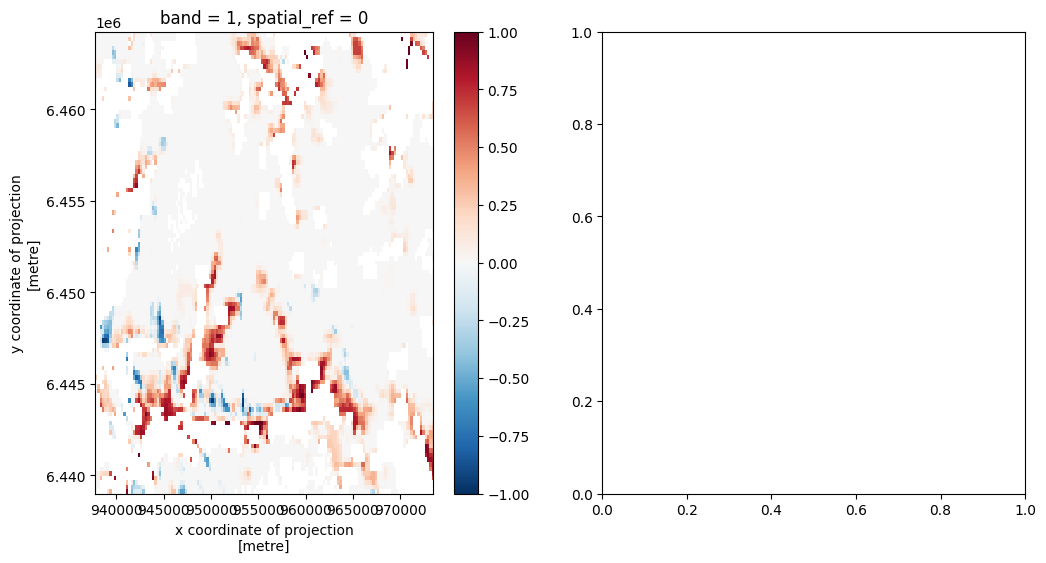

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
# obs = obs.rename({'xx': 'x', 'yy': 'y'})
(background.mean(dim="member").data_vars["fsc"] - obs.data_vars["SCF"]).plot.imshow(ax=axs[0])